In [1]:
import tools.sitnikov_integrator as sit
import numpy as np
import matplotlib.pyplot as plt

In [2]:
e = 0.5
sit.set_eps(e)

In [14]:
e = 0.5
sit.set_eps(e)

Nv = 20
Nt = 10
Tmax = 6000
rtol = 1e-3
atol = 1e-6

v_arr = np.linspace(1.7, 2.5, Nv)
t_arr = np.linspace(-0.3, 0.3, Nt)

t_esc_arr = np.zeros((Nt, Nv))

for i in range(Nt):
    for j in range(Nv):
        t_esc_arr[i][j] = sit.escape_time(t = t_arr[i], v=v_arr[j], Tmax = Tmax)

    

C:\Users\leona\AppData\Local\Temp\ipykernel_10444\4168796919.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


'figures\\figure#17.png'

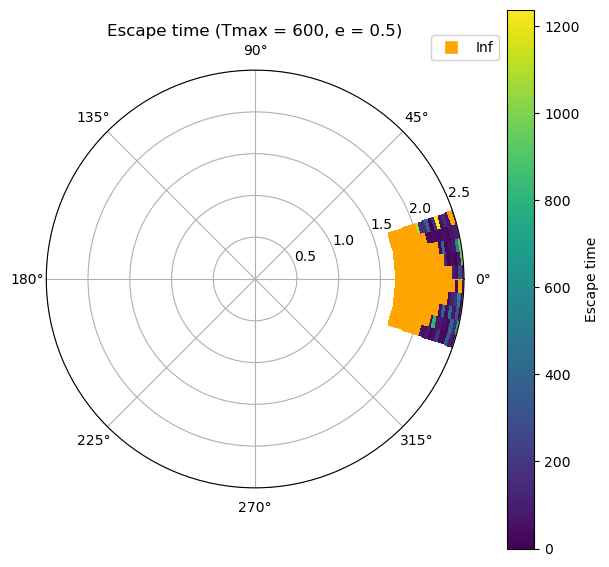

In [15]:
from tools.sitnikov_plotter import escape_time_region_tv_color_figure

fig, ax = escape_time_region_tv_color_figure(t_arr=t_arr, v_arr=v_arr, t_esc_arr=t_esc_arr, Tmax = Tmax)
ax.set_title("Escape time (Tmax = 600, e = 0.5)")
fig.show()
from tools.save_figure import save_figure

save_figure(fig)

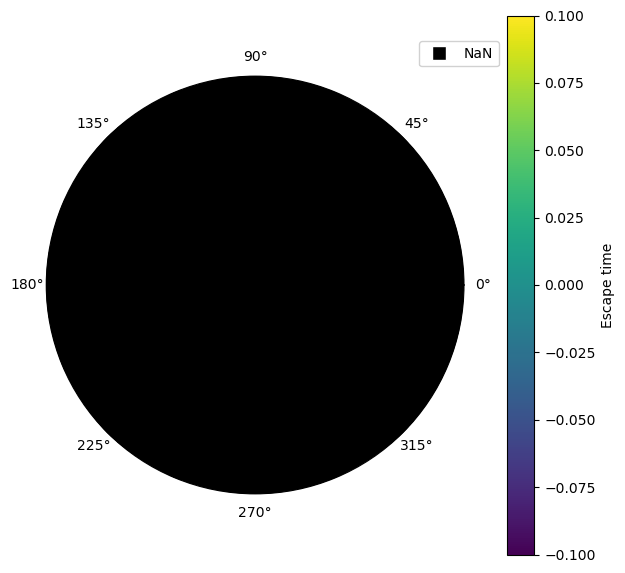

In [5]:
from matplotlib.colors import Normalize, ListedColormap

# assume t_arr (Nt,) in radians, v_arr (Nv,), t_esc_arr shape (Nt, Nv)
Theta, R = np.meshgrid(t_arr, v_arr, indexing='ij')   # shapes (Nt, Nv)
data = t_esc_arr.copy()

# Identify finite / infinite / NaN entries
is_nan = np.isnan(data)
is_inf = np.isinf(data)
is_finite = np.isfinite(data)

# Masked array for finite data only (NaN and inf masked out)
data_finite = np.ma.masked_where(~is_finite, data)

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(7,7))

# continuous colormap for finite values
cmap = plt.cm.viridis
mesh = ax.pcolormesh(Theta, R, data_finite, cmap=cmap, shading='auto', zorder=1)
cbar = fig.colorbar(mesh, ax=ax, pad=0.08)
cbar.set_label('Escape time')

# overlay inf cells as a solid orange region
if np.any(is_inf):
    inf_plot = np.ma.masked_where(~is_inf, np.ones_like(data))
    cmap_inf = ListedColormap(['orange'])
    ax.pcolormesh(Theta, R, inf_plot, cmap=cmap_inf, shading='auto', zorder=2)

# overlay NaN cells as a solid black region
if np.any(is_nan):
    nan_plot = np.ma.masked_where(~is_nan, np.ones_like(data))
    cmap_nan = ListedColormap(['black'])
    ax.pcolormesh(Theta, R, nan_plot, cmap=cmap_nan, shading='auto', zorder=3)

ax.set_ylim(0, v_arr.max())

# legend for the special regions
handles = []
labels = []
if np.any(is_inf):
    from matplotlib.lines import Line2D
    handles.append(Line2D([], [], marker='s', color='w', markerfacecolor='orange', markersize=10, linestyle='None'))
    labels.append('Inf')
if np.any(is_nan):
    from matplotlib.lines import Line2D
    handles.append(Line2D([], [], marker='s', color='w', markerfacecolor='black', markersize=10, linestyle='None'))
    labels.append('NaN')
if handles:
    ax.legend(handles=handles, labels=labels, loc='upper right', bbox_to_anchor = (1.1, 1.1), framealpha=0.9)

plt.show()


In [6]:
from tools.sitnikov_plotter import escape_time_tv_color_figure

fig, ax = escape_time_tv_color_figure(t_arr = t_arr, v_arr = v_arr, t_esc_arr=t_esc_arr, Tmax = Tmax, dot_size= 2)

ax.set_title("Test escape time plot")

fig.show()

ImportError: cannot import name 'escape_time_tv_color_figure' from 'tools.sitnikov_plotter' (c:\Users\leona\OneDrive - Universitat Politècnica de Catalunya\Desktop\ReboundTests\sitnikov\tools\sitnikov_plotter.py)

In [ ]:
from tools.save_figure import save_figure

out_path = save_figure(fig=fig)
print(out_path)

figures\figure#15.png
